In [7]:
import os
import sys
import json
import numpy as np
from glob import glob
from collections import defaultdict
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist

sys.path.append("../../")
from modules.utils import *

## Distances (full video)

../../my_rps_dataset/features_coords
Min num frames in test set: 54


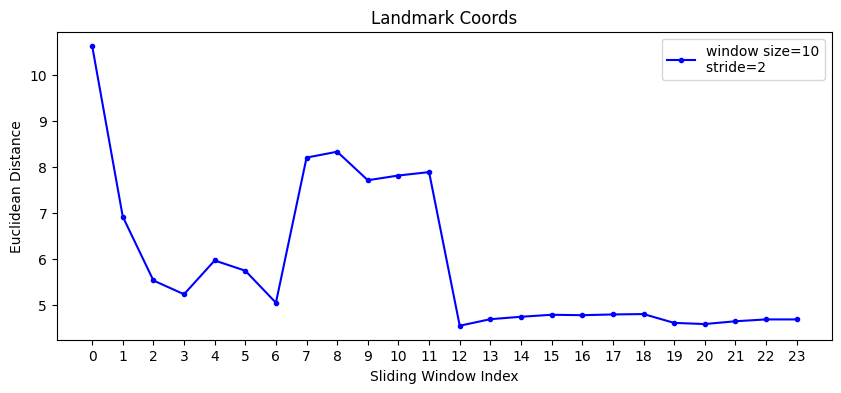

../../my_rps_dataset/features_angles
Min num frames in test set: 54


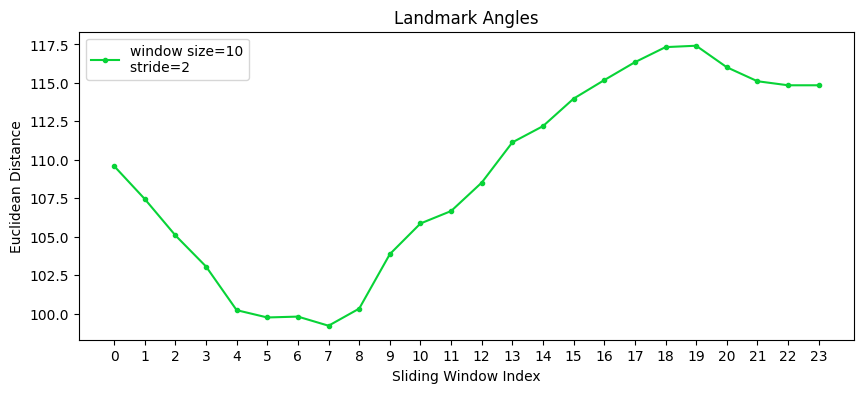

In [8]:
new_features = {}
lines_per_feat = []

for DATA_DIR in DATA_DIR_LIST: # coords, angles
    print(DATA_DIR)
    datasets = load_splits(SPLIT_FILE, DATA_DIR)
    train_set, test_set = datasets["train"], datasets["test"]
    MIN_NUM_FRAMES = min([s["landmarks"].shape[0] for s in test_set])
    print(f"Min num frames in test set: {MIN_NUM_FRAMES}")

    feature_rep_name = DATA_DIR.split('_')[-1]
    new_features[feature_rep_name] = {}

    for r in OBS_RATIOS[-1:]:
        for s in test_set:
            Xfull = sequence_to_feature_matrix(
                s["landmarks"][-MIN_NUM_FRAMES:], use_vel=False
            )
            Xfull = np.nan_to_num(Xfull)
            T = Xfull.shape[0]
            t_obs = max(1, int(np.round(T * r / 100.0)))
            prefix = Xfull[:t_obs]

            # CHUNK_SIZE, STRIDE = 5, 1
            CHUNK_SIZE, STRIDE = 10, 2

            chunks, idx = get_overlapping_chunks(
                prefix, chunk_size=CHUNK_SIZE, overlap=STRIDE
            )

            sample_seq = []
            for i, (c, (start, end)) in enumerate(zip(chunks, idx)):
                if c.shape[0] < CHUNK_SIZE:
                    print("  Skipping, too short")
                    continue
                else:
                    sample_seq.append(c)
            new_features[feature_rep_name][s["id"]] = np.array(sample_seq)
            
    # Compute pairwise distances for each chunk index across samples
    N_CHUNKS = list(new_features[feature_rep_name].values())[0].shape[0]
    res = []
    res_var = []

    for k in range(N_CHUNKS):
        chunks_at_k = []

        for sample_id, sample_seq in new_features[feature_rep_name].items():
            chunks_at_k.append(sample_seq[k])  # shape (5, D) where D can be 63 for coords and 5 for angles

        # Stack to get (n_samples, 5, D)
        chunks_at_k = np.stack(chunks_at_k, axis=0)
        
        # Compute pairwise distances between all samples at each time step
        N_SLIDING_WINDOWS = chunks_at_k.shape[1]
        dist = np.array(
            [
                pdist(chunks_at_k[:, i, :], metric="euclidean")
                for i in range(N_SLIDING_WINDOWS)
            ]
        )

        res.append(dist.mean())
        # compute standard error of the mean across samples
        res_var.append(dist.std() / np.sqrt(dist.shape[0]))

    lines_per_feat.append((feature_rep_name, res))
    feat_color = {'coords': 'blue', 'angles': '#08D337', 'angles2': 'orange'}
    # Visualize variance for the first chunk across time steps
    plt.figure(figsize=(10, 4))
    plt.plot(res, marker=".", color=feat_color[feature_rep_name],  
             label=f"window size={CHUNK_SIZE}\nstride={STRIDE} ")
    plt.legend()
    # plt.xticks(range(len(res)), [f"Chunk {i}" for i in range(len(res))])
    plt.xticks(range(len(res)))
    if False:
        plt.fill_between(
            range(len(lines_per_feat[0][1])),
            np.array(res) - np.array(res_var),
            np.array(res) + np.array(res_var),
            color="gray",
            alpha=0.3,
        )
    plt.title(f"Landmark {feature_rep_name.capitalize()}")
    plt.xlabel("Sliding Window Index")
    plt.ylabel("Euclidean Distance")
    #plt.grid()
    plt.show()

## Distances (cropped video)

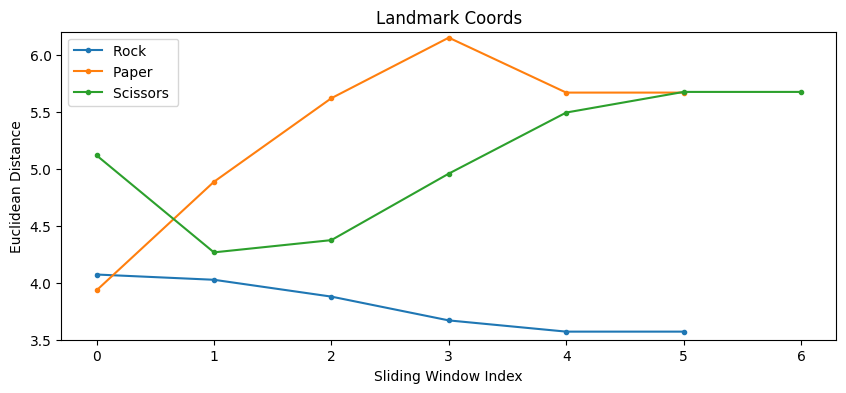

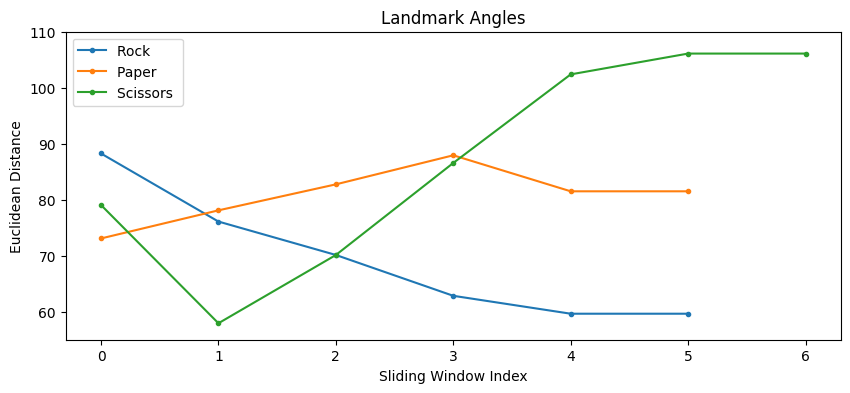

In [10]:
for DATA_DIR in DATA_DIR_LIST:
    datasets = load_splits_cropped(f"../../../{ALIGN_DIR}", DATA_DIR)
    rock_data, paper_data, scissors_data = datasets["rock"], datasets["paper"], datasets["scissors"]
    # print(f"Rock samples: {len(rock_data)}, Paper samples: {len(paper_data)}, Scissors samples: {len(scissors_data)}")
    feature_rep_name = DATA_DIR.split('_')[-1]
    plt.figure(figsize=(10, 4))
    
    for gesture_type in ['rock', 'paper', 'scissors']:
        MIN_LENGTH = min([sample['landmarks'].shape[0] for sample in datasets[gesture_type]])
        new_features = {}
        for sample in datasets[gesture_type]:
            X = sequence_to_feature_matrix(sample["landmarks"][:MIN_LENGTH])
            X = np.nan_to_num(X)
            CHUNK_SIZE, STRIDE = 3, 1
            chunks, idx = get_overlapping_chunks(
                X, chunk_size=CHUNK_SIZE, overlap=STRIDE
            )
            
            sample_seq = []
            for i, (c, (start, end)) in enumerate(zip(chunks, idx)):
                if c.shape[0] < CHUNK_SIZE:
                    continue
                    # pad_width = CHUNK_SIZE - c.shape[0]
                    # c = np.pad(c, ((0, pad_width), (0, 0)), mode='edge')
                else: 
                    sample_seq.append(c)
            new_features[sample['id']] = np.array(sample_seq)
        
        N_CHUNKS = list(new_features.values())[0].shape[0]
        res = []

        for k in range(N_CHUNKS):
            chunks_at_k = []

            for sample_id, sample_seq in new_features.items():
                chunks_at_k.append(sample_seq[k])  # shape (CHUNK_SIZE, D) where D can be 63 for coords and 5 for angles

            # Stack to get (n_samples, CHUNK_SIZE, D)
            chunks_at_k_stacked = np.stack(chunks_at_k, axis=0)

            # Compute pairwise distances between all samples at each time step
            # dist = np.array([pdist(chunks_at_k_stacked[:, i, :], metric="euclidean") for i in range(chunks_at_k_stacked.shape[1])])
            dist = pdist(chunks_at_k_stacked.reshape(chunks_at_k_stacked.shape[0], -1), metric="euclidean")
            res.append(dist.mean())

        #feat_color = {'coords': 'blue', 'angles': '#08D337', 'angles2': 'orange'}

        # Visualize
        # plt.plot(res, marker=".", color=feat_color[feature_rep_name], label=f"window size={CHUNK_SIZE}\nstride={STRIDE} ")
        plt.plot(res, marker=".", label=f"{gesture_type.capitalize()} ")
        
        if feature_rep_name == "coords": 
            plt.ylim(3.5, 6.2)
        else: 
            plt.ylim(55, 110)
    plt.xticks(range(len(res)))
    plt.title(f"Landmark {feature_rep_name.capitalize()}")
    plt.xlabel("Sliding Window Index")
    plt.ylabel("Euclidean Distance")
    plt.legend()
    plt.show()
            